# EDA - PWC Multiclass Dataset
Analisi esplorativa del dataset multiclasse estratto da Papers With Code (PWC).
Dataset: `../data/processed/pwc_ai_multiclass.csv`

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setup stile plot
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

In [22]:
# 1. Caricamento Dati
df_multiclass = pd.read_csv('../data/processed/pwc_ai_multiclass.csv')
# Assicuriamoci che tutto il testo testuale in description sia normalizzato a minuscolo
df_multiclass['description'] = df_multiclass['description'].str.lower()
print(f"Dimensioni dataset: {df_multiclass.shape}")
display(df_multiclass.head())

Dimensioni dataset: (395581, 2)


,description,label
0,can evolving networks be inferred and modeled ...,Research
1,pac-bayes bounds have been proposed to get ris...,Research
2,this paper investigates the automated recognit...,Research
3,we analyze algorithms for approximating a func...,Research
4,in order to provide the right type of assistan...,Research


In [23]:
# 2. Controllo valori mancanti
print("Valori mancanti per colonna:")
print(df_multiclass.isnull().sum())

Valori mancanti per colonna:
description    3437
label             0
dtype: int64


/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_19527/3432389342.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_multiclass, y='label', order=df_multiclass['label'].value_counts().index, palette='viridis')


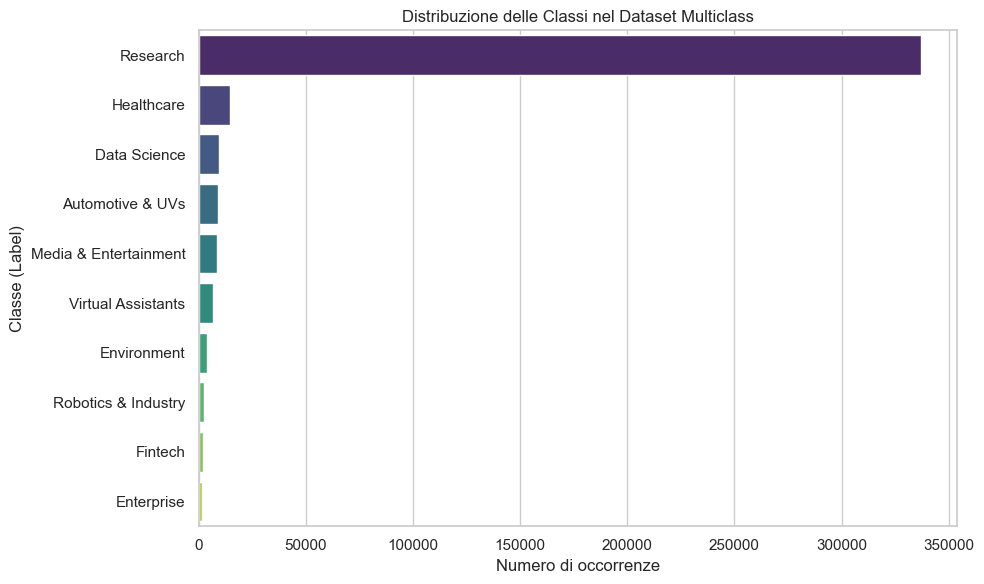

In [24]:
# 3. Distribuzione delle Classi (Label)
plt.figure(figsize=(10, 6))
sns.countplot(data=df_multiclass, y='label', order=df_multiclass['label'].value_counts().index, palette='viridis')
plt.title('Distribuzione delle Classi nel Dataset Multiclass')
plt.xlabel('Numero di occorrenze')
plt.ylabel('Classe (Label)')
plt.tight_layout()
plt.show()

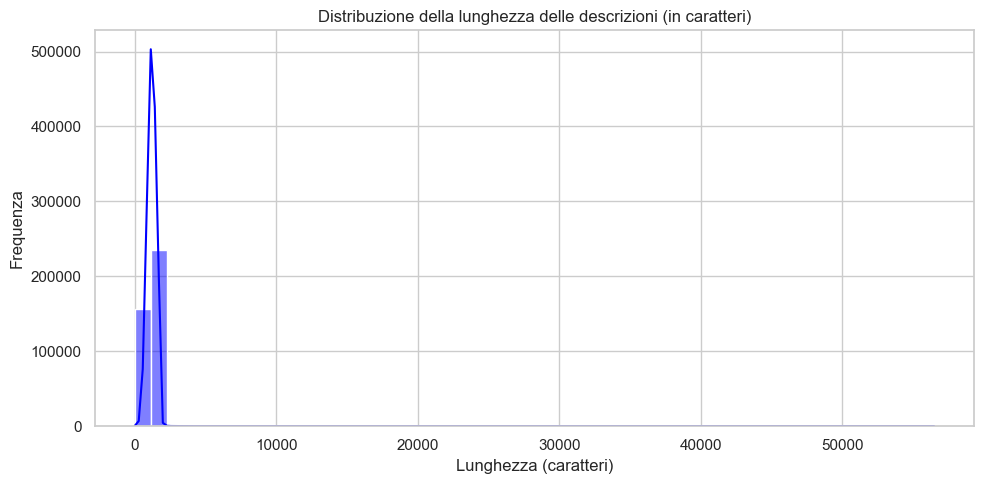

In [25]:
# 4. Analisi della lunghezza delle descrizioni
df_multiclass['desc_length'] = df_multiclass['description'].astype(str).str.len()

plt.figure(figsize=(10, 5))
sns.histplot(df_multiclass['desc_length'], bins=50, kde=True, color='blue')
plt.title('Distribuzione della lunghezza delle descrizioni (in caratteri)')
plt.xlabel('Lunghezza (caratteri)')
plt.ylabel('Frequenza')
plt.tight_layout()
plt.show()

# 6. Ri-classificazione della Categoria "Research"

I record classificati come `Research` sono spesso abstract di paper. Il gergo accademico fa finire l'articolo nella macro-categoria `Research` anche se il tema applicativo è un altro (es: Healthcare, NLP).
Eseguiamo una "seconda passata" sui record attualmente `Research` utilizzando keyword applicative per farli confluire nelle categorie corrette.

In [26]:
import re

# Definiamo regex più specializzate per intercettare i veri casi d'uso
# ignorando la terminologia accademica (paper, research, study, etc.)
refinement_regex = {
    "Healthcare": [r'\bhealthcare\b', r'\bmedical(?:ly)?\b', r'\bclinic(?:al|s)\b', r'\bdiseas(?:e|es)\b', 
                   r'\bpatien[ts]?\b', r'\behr[s]?\b', r'\bhealth[s]?\b', r'\bgenomi[cs]?\b', 
                   r'\bcancer[s]?\b', r'\btumo[ur]s?\b', r'\bdiagnos(?:is|tics|tically)\b',
                   r'\btherap(?:y|ies)\b', r'\bpharma(?:cy|ceutical)?\b', r'\bpathology\b', r'\bsurger(?:y|ies)\b', r'\bcardio(?:logy)?\b', r'\bneuro(?:logy)?\b'],
    "Media & Entertainment": [r'\bsocial\s+media\b', r'\bvideo[s]?\b', r'\bmusic\b', r'\bmovie[s]?\b', 
                              r'\bgam(?:e|es|ing)\b', r'\bdeepfake[s]?\b', r'\bfake\s+news\b', 
                              r'\bgenerative\s+art\b', r'\bmultimedia\b',
                              r'\bstreaming\b', r'\bcontent\s+creation\b', r'\banimation\b', r'\baudio\b', r'\bentertainment\b', r'\bcinema\b'],
    "Fintech": [r'\bfi[nn](?:ance|ancial)\b', r'\bbank(?:ing|s)\b', r'\btrading\b', r'\bstock[s]?\b', 
                r'\bfraud(?:ulent)?\b', r'\bcredit[s]?\b', r'\bcrypt(?:o|ocurrency)\b', r'\binsurance\b',
                r'\bwealth\b', r'\binvest(?:ment|ing)\b', r'\bportfolio\b', r'\bfund[s]?\b', r'\bfintech\b', r'\bpayment[s]?\b', r'\bmarket(?:s)?\b'],
    "Automotive & UVs": [r'\bautonomous\b', r'\bs[eè]lf[\-\s]?driving\b', r'\bvehicl[e|es]\b', 
                                 r'\bdrone[s]?\b', r'\buav[s]?\b', r'\btraffic\b', r'\badas\b',
                                 r'\bcar[s]?\b', r'\bdriving\b', r'\brobotaxi[s]?\b', r'\bnavigation\b', r'\btransport(?:ation)?\b', r'\bautomotive\b'],
    "Robotics & Industry": [r'\brobot[s]?\b', r'\brobotic[s]?\b', r'\bindustr[y|ial]\b', r'\bmanufactur(?:e|ing)\b', 
                            r'\bsupply\s+chain\b', r'\biot\b', r'\bpredictive\s+maintenance\b', r'\bwarehouse\b',
                            r'\bfactor(?:y|ies)\b', r'\bproduction\b', r'\bautomation\b', r'\blogistics\b', r'\bcontrol\s+systems\b', r'\bmachiner(?:y)?\b'],
    "Environment": [r'\benvironmen[tal]?\b', r'\bclimat(?:e|ic)\b', r'\bagricultur[e|al]\b', r'\bsustainabilit[y]\b', 
                    r'\brecycl(?:e|ing)\b', r'\benergy\b', r'\bweather\b', r'\bpolluti(?:on|ants)\b',
                    r'\bfarm(?:ing|s)?\b', r'\bwater\b', r'\bforest(?:ry)?\b', r'\bcarbon\b', r'\becolog(?:y|ical)?\b', r'\brenewable[s]?\b', r'\bsolar\b'],
    "Virtual Assistants": [r'\bchatbot[s]?\b', r'\bdialog(?:ue)?\b', r'\bconversational\b', r'\bspeech\b', 
                           r'\bvoic(?:e|es)\b', r'\bllm[s]?\b', r'\bquestion\s+answering\b', r'\bassistant[s]?\b',
                           r'\bnlp\b', r'\btext-to-speech\b', r'\bspeech-to-text\b', r'\blanguage\s+model[s]?\b', r'\bcustomer\s+support\b'],
    "Enterprise": [r'\benterpris(?:e|es)\b', r'\bhuman\s+resources\b', r'\bmarketing\b', r'\bcustomer[s]?\b', 
                   r'\brpa\b', r'\be-commerce\b', r'\bbusiness\b', r'\bsales\b',
                   r'\bhr\b', r'\brecruit(?:ment|ing)\b', r'\badvertis(?:ing|ement)\b', r'\bmanagement\b', r'\bcrm\b', r'\bworkflow[s]?\b'],
    "Data Science": [r'\bdata\s+science\b', r'\banomaly\s+detection\b', r'\bfeature\s+engineering\b', 
                     r'\bautoml\b', r'\bbig\s+data\b', r'\bdatabase[s]?\b',
                     r'\banalytic[s]?\b', r'\btime\s+series\b', r'\bdata\s+mining\b', r'\bpredictive\s+modeling\b', r'\bclustering\b', r'\bdata\s+warehouse[s]?\b']
}

compiled_refinements = {cat: re.compile('|'.join(kws), re.IGNORECASE) for cat, kws in refinement_regex.items()}

def refine_research_label(text):
    text_lower = str(text).lower()
    for cat, regex in compiled_refinements.items():
        if regex.search(text_lower):
            return cat
    return "Research" # Se non trovo nulla, rimane Research

# Contiamo quanti record prima della passata
mask_research = df_multiclass['label'] == 'Research'
print(f"Record classificati come 'Research' prima: {mask_research.sum()}")

# Applichiamo la funzione solo sui record attualmente in "Research", normalizzando anche qui se necessario
# Il map della regex sul testo minuscolo è già in text_lower, ma normalizziamo anche la colonna in input
df_multiclass.loc[mask_research, 'label'] = df_multiclass.loc[mask_research, 'description'].str.lower().apply(refine_research_label)

# Verifichiamo l'impatto
new_mask_research = df_multiclass['label'] == 'Research'
diff = mask_research.sum() - new_mask_research.sum()
print(f"Record classificati come 'Research' dopo: {new_mask_research.sum()}")
print(f"Record ricollocati: {diff}")
print("\nNuova distribuzione:")
print(df_multiclass['label'].value_counts())

Record classificati come 'Research' prima: 337167
Record classificati come 'Research' dopo: 162613
Record ricollocati: 174554

Nuova distribuzione:
label
Research                 162613
Virtual Assistants        55248
Healthcare                39062
Media & Entertainment     37795
Data Science              24835
Automotive & UVs          24102
Environment               21496
Robotics & Industry       16079
Fintech                    9119
Enterprise                 5232
Name: count, dtype: int64


/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_19527/3109740517.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_multiclass, y='label', order=df_multiclass['label'].value_counts().index, palette='magma')


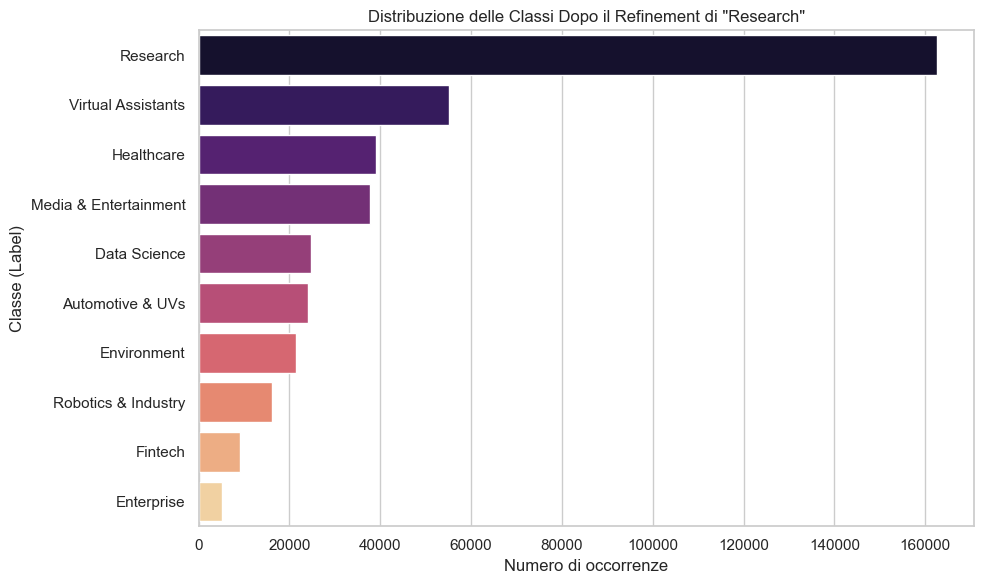

In [27]:
# 7. Grafico della Nuova Distribuzione
plt.figure(figsize=(10, 6))
sns.countplot(data=df_multiclass, y='label', order=df_multiclass['label'].value_counts().index, palette='magma')
plt.title('Distribuzione delle Classi Dopo il Refinement di "Research"')
plt.xlabel('Numero di occorrenze')
plt.ylabel('Classe (Label)')
plt.tight_layout()
plt.show()

In [33]:
# 8. Salvataggio 
# Sovrascriviamo o salviamo come nuovo
out_path = '../data/processed/pwc_ai_multiclass.csv'
df_multiclass.to_csv(out_path, index=False)
print(f"Nuovo dataset salvato in: {out_path}")

Nuovo dataset salvato in: ../data/processed/pwc_ai_multiclass.csv


In [36]:
# 9. Creazione dataset bilanciato
SAMPLES_PER_CLASS = 10000

# Campionamento di 10.000 record per ogni classe
# Utilizziamo un ciclo esplicito e pd.concat per bypassare i bug di indicizzazione di groupby.apply() in Pandas
sampled_dfs = []
for label, group in df_multiclass.groupby('label'):
    sampled = group.sample(n=SAMPLES_PER_CLASS, replace=(len(group) < SAMPLES_PER_CLASS), random_state=42)
    sampled_dfs.append(sampled)

df_balanced = pd.concat(sampled_dfs).reset_index(drop=True)

print(f"Dimensioni dataset bilanciato: {df_balanced.shape}")
print("\nDistribuzione classi:")
print(df_balanced['label'].value_counts())

print("\n--- Esempi di descrizioni per classe ---")
for label in df_balanced['label'].unique():
    print(f"\n====================\nCLASSE: {label}\n====================")
    examples = df_balanced[df_balanced['label'] == label].head(3)
    for i, desc in enumerate(examples['description'], 1):
        print(f"{i}. {desc}\n")

# Salvataggio
out_path_balanced = '../data/processed/pwc_ai_multiclass_balanced.csv'
df_balanced.to_csv(out_path_balanced, index=False)
print(f"Dataset bilanciato salvato in: {out_path_balanced}")

Dimensioni dataset bilanciato: (100000, 3)

Distribuzione classi:
label
Automotive & UVs         10000
Data Science             10000
Enterprise               10000
Environment              10000
Fintech                  10000
Healthcare               10000
Media & Entertainment    10000
Research                 10000
Robotics & Industry      10000
Virtual Assistants       10000
Name: count, dtype: int64

--- Esempi di descrizioni per classe ---

CLASSE: Automotive & UVs
1. we build on the theory of ontology logs (ologs) created by spivak and kent, and define a notion of wiring diagrams. in this article, a wiring diagram is a finite directed labelled graph. the labels correspond to types in an olog; they can also be interpreted as readings of sensors in an autonomous system. as such, wiring diagrams can be used as a framework for an autonomous system to form abstract concepts. we show that the graphs underlying skeleton wiring diagrams form a category. this allows skeleton wiring diagr